In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from collections import Counter
import seaborn as sns
from matplotlib import pyplot as plt

import pickle
import glob
import os

# import lifelines
# import patchworklib as pw

In [2]:
from annot import *
from utils import get_annotation
annotationdf = get_annotation()

In [4]:
CELL_LINES = ['a549', 'du145', 'mcf7', 'ovca420']
TREATMENTS = ['tgfb1', 'egf', 'tnf']
CELL_LINE_to_CANCERTYPE = {'a549':'LUAD', 'du145':'PRAD', 'mcf7':'BRCA', 'ovca420':'OV'}
CELL_LINE_to_tissue = {'a549':'lung', 'du145':'prostate', 'mcf7':'breast', 'ovca420':'ovarian'}

# 1A: venn diagrams

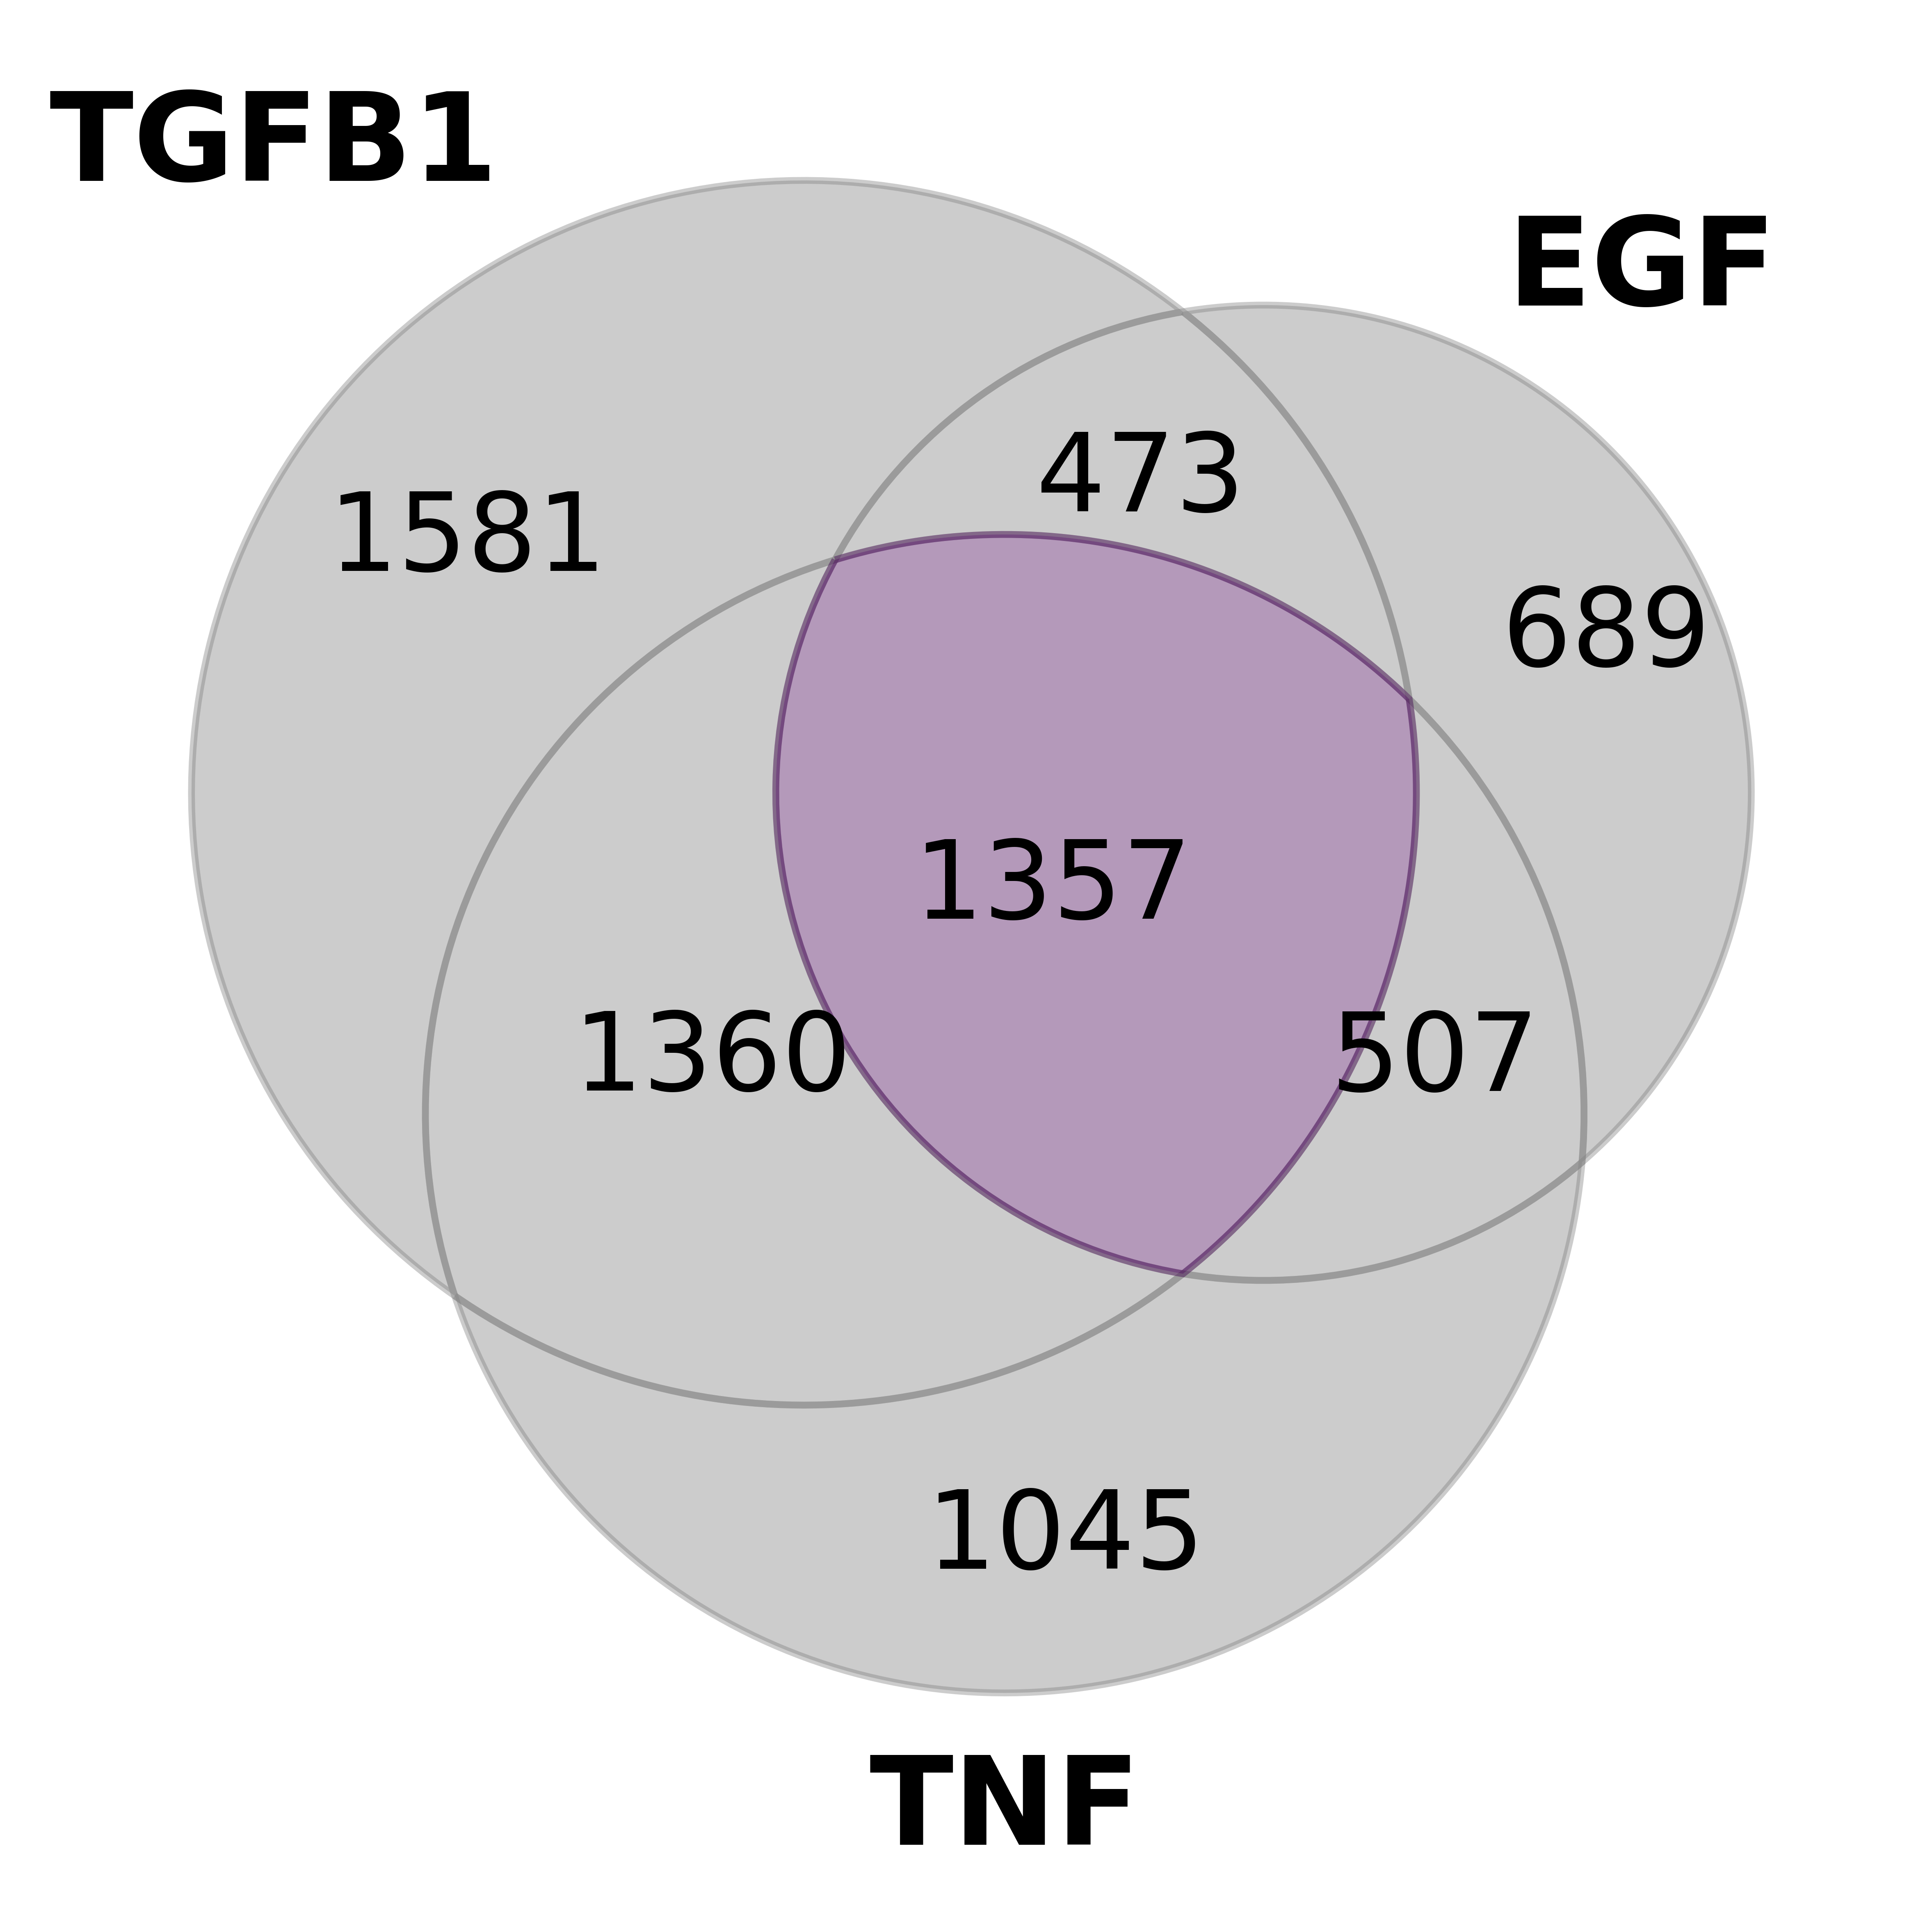

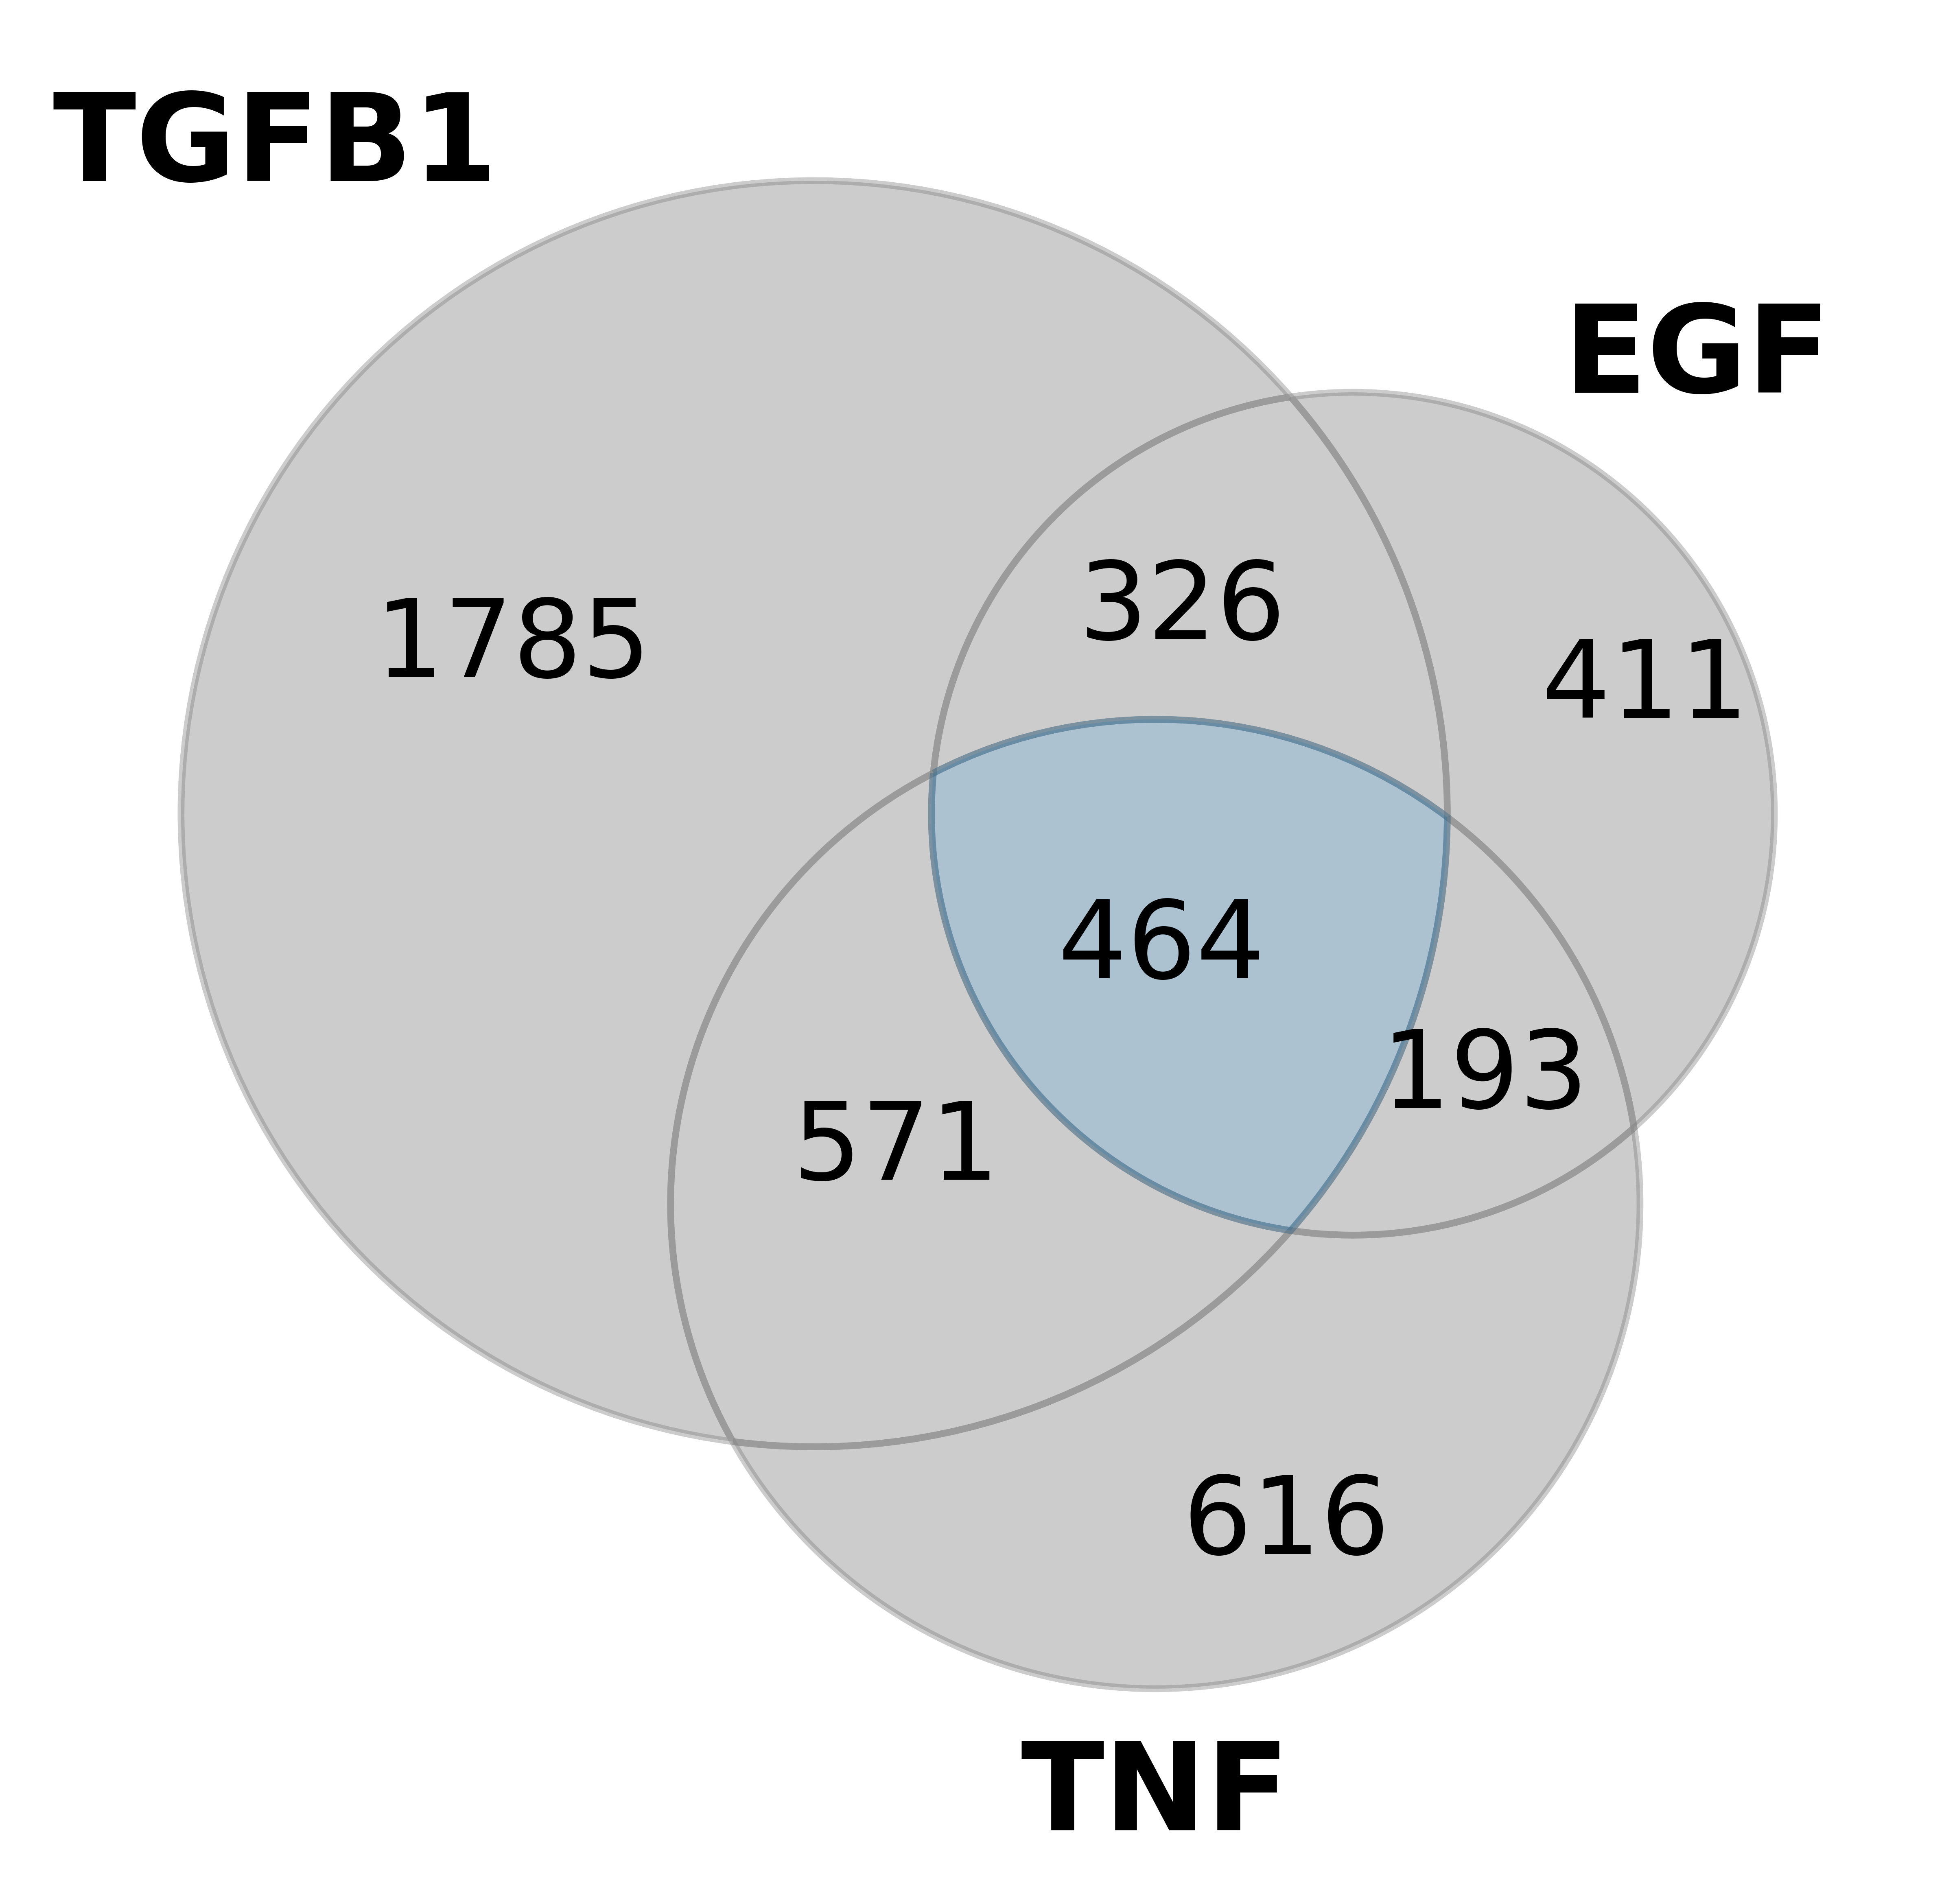

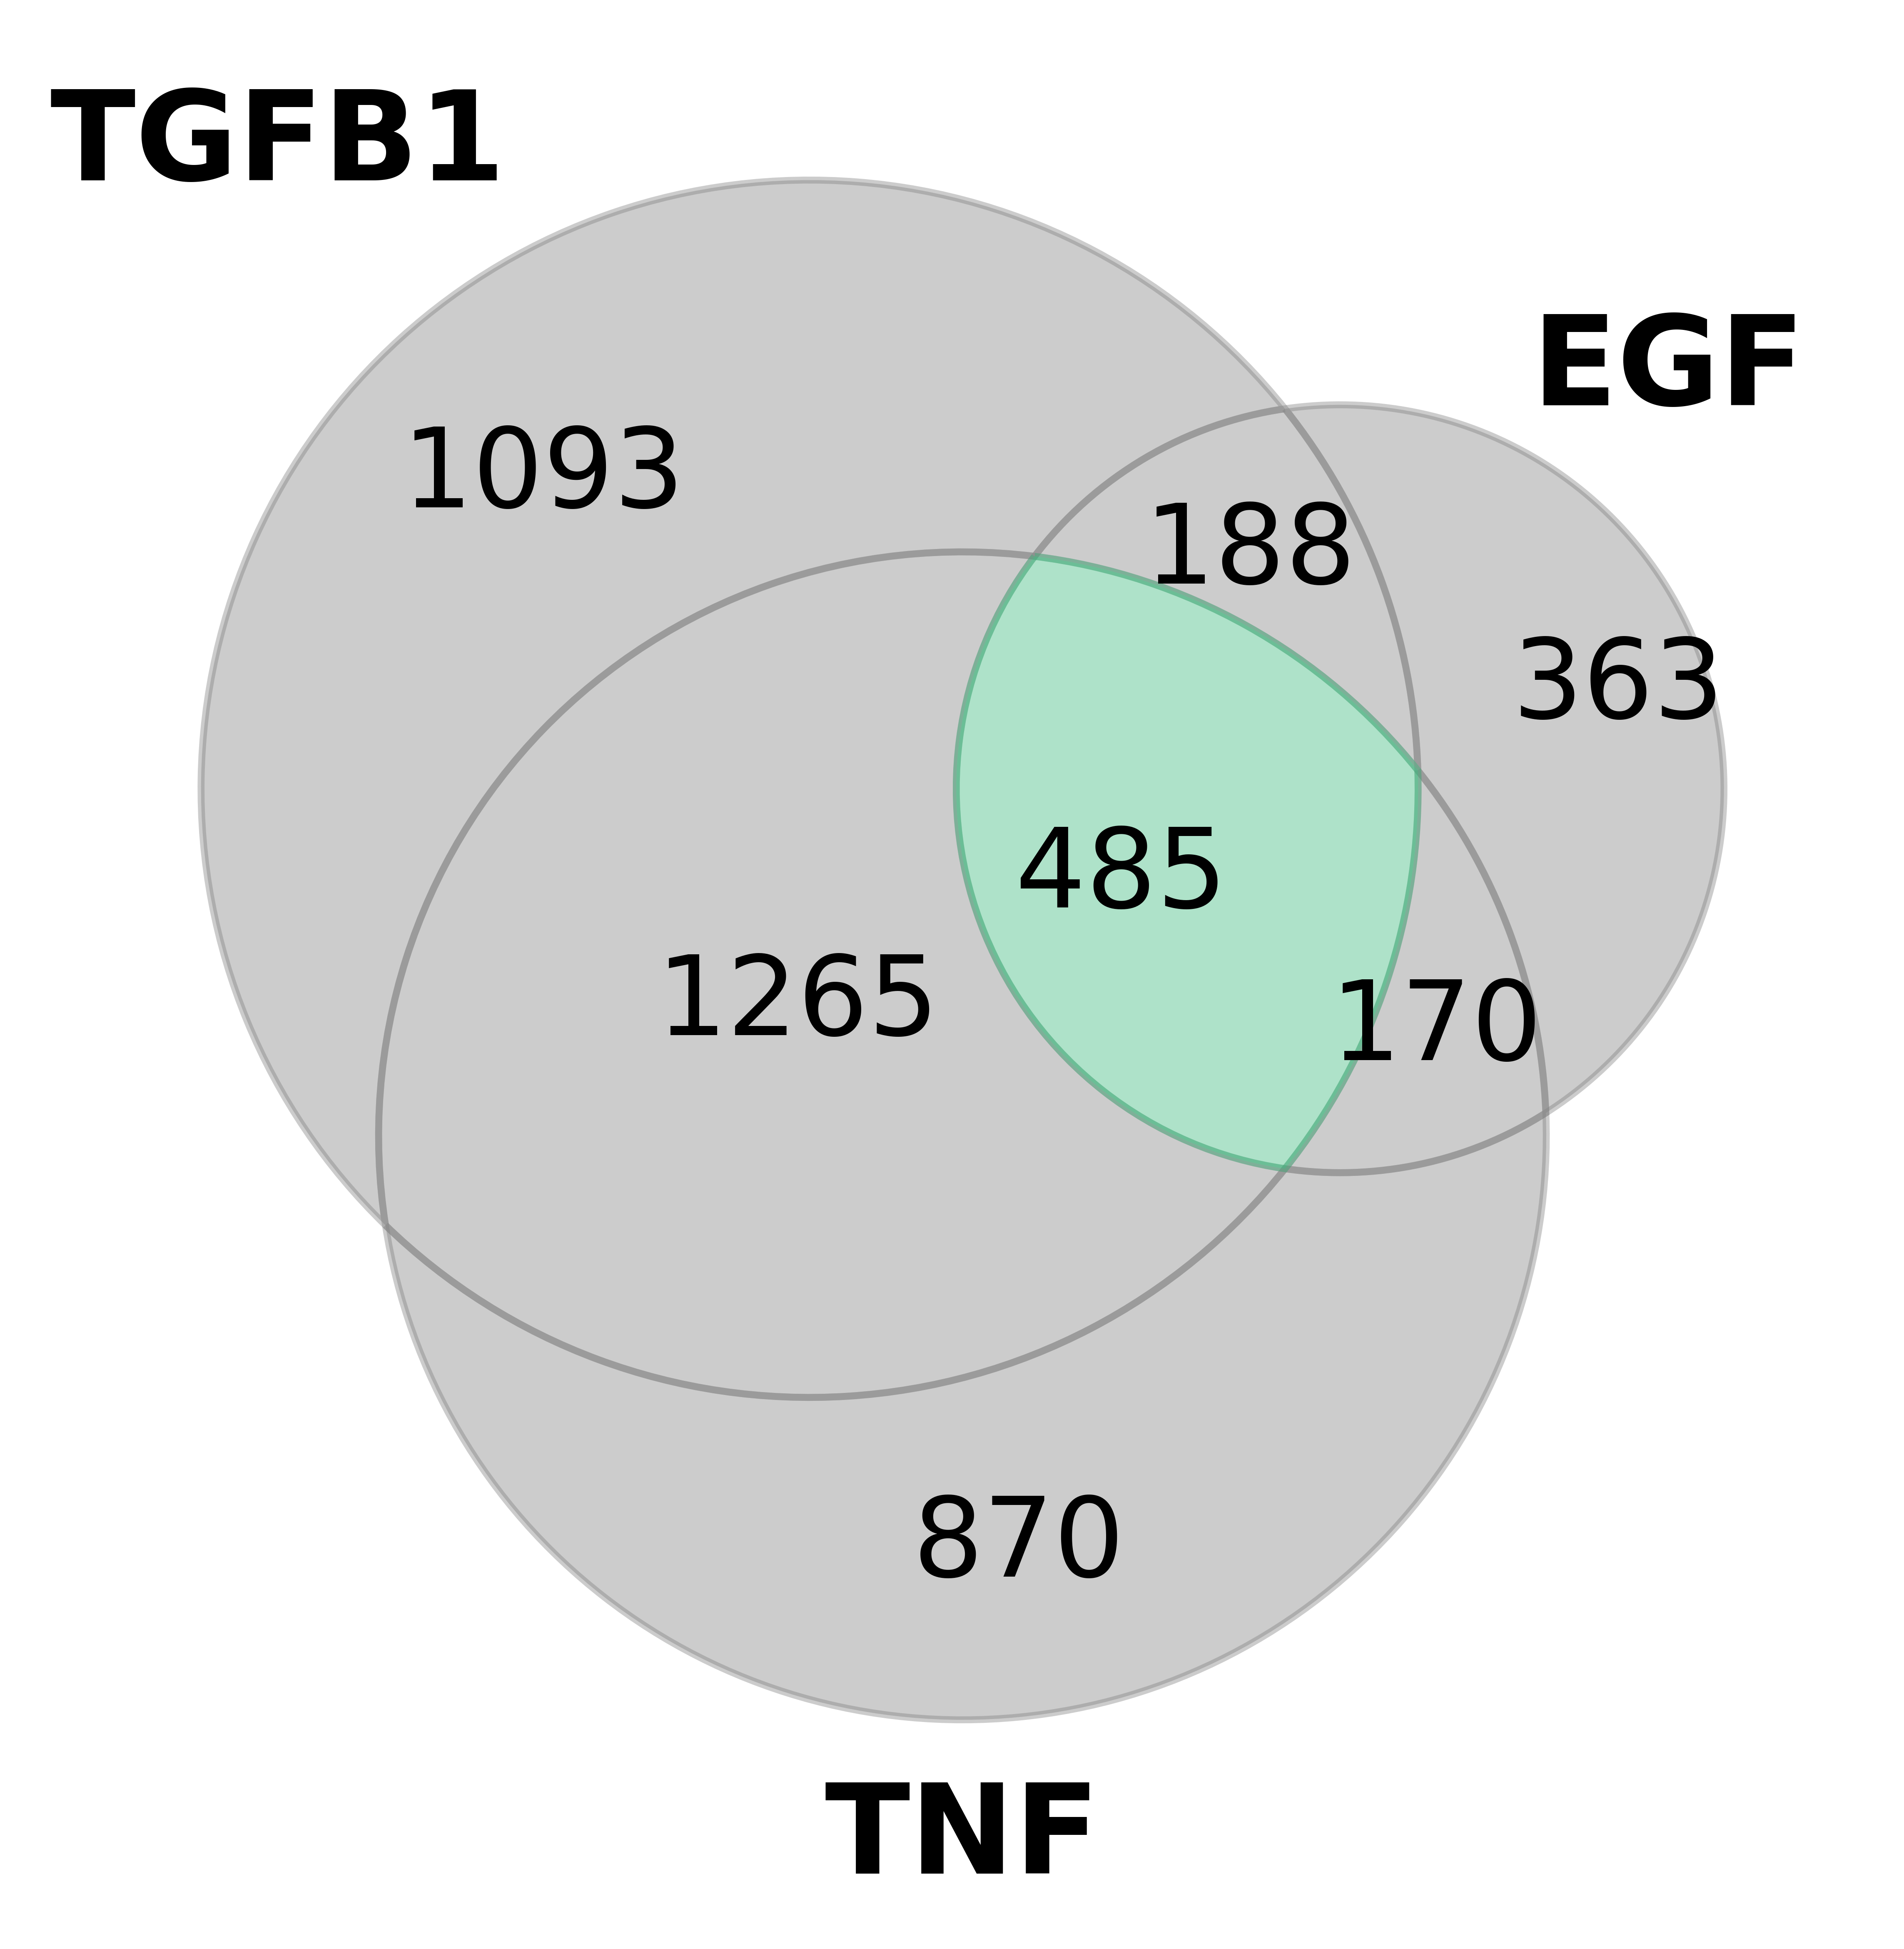

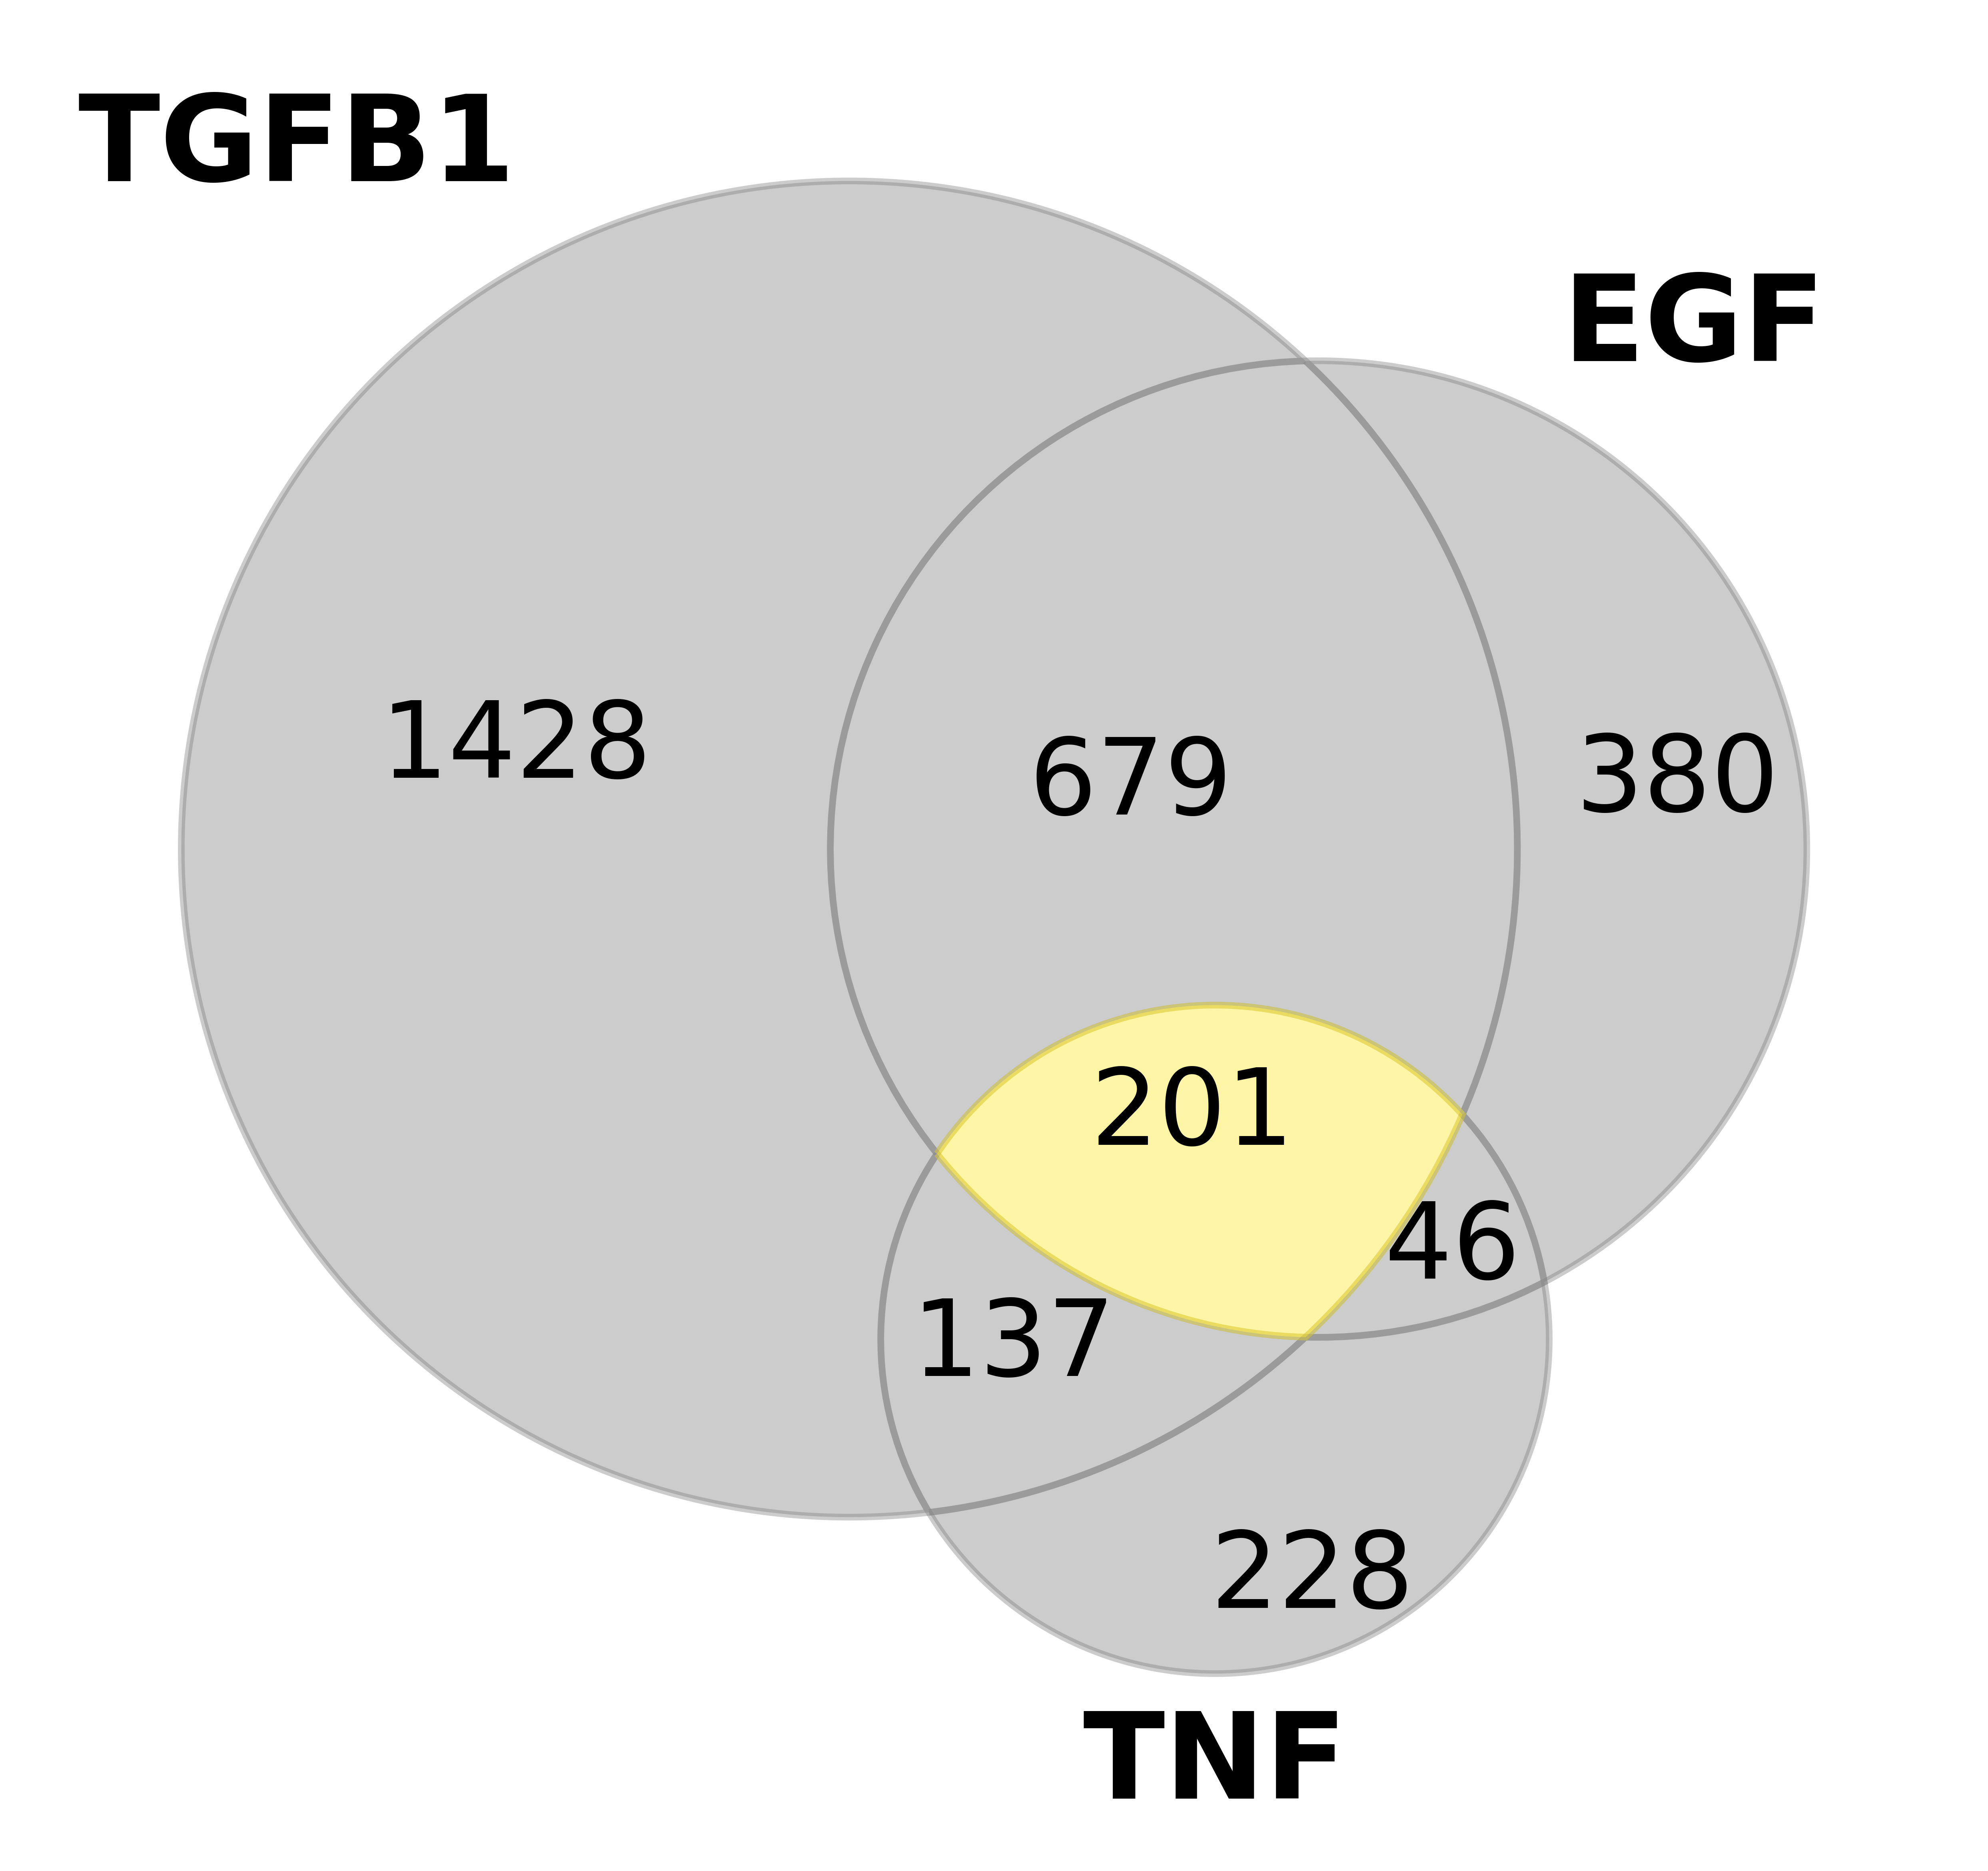

In [9]:
# CELL_LINES = ['a549', 'du145', 'mcf7', 'ovca420']
# TREATMENTS = ['tgfb1', 'egf', 'tnf']
# CELL_LINE_to_CANCERTYPE = {'a549':'LUAD', 'du145':'PRAD', 'mcf7':'BRCA', 'ovca420':'OV'}
# CELL_LINE_to_tissue = {'a549':'lung', 'du145':'prostate', 'mcf7':'breast', 'ovca420':'ovarian'}
# from annot import *
# from itertools import chain
# from emt import plot_emt_treatment_genes

# from matplotlib_venn import venn3

axes1 = plot_emt_treatment_genes(annotationdf)

In [27]:
import patchworklib as pw
from emt import read_emt_treatment_genes
g0_treatment = read_emt_treatment_genes(annotationdf)

# from matplotlib import rc
# rc('font', weight='bold')
# ax1 = pw.Brick(figsize=(10,8))
# v = venn(celltype_sets, ax=ax1, fontsize=18)
# ax1.savefig(
#     f'{PROJECT_location}/Figures/Fig_1a_venn_consensus.png', dpi=700
# )

3
a549 7012 (366, 2) 1357
3
du145 4366 (94, 2) 464
3
mcf7 4434 (369, 2) 485
3
ovca420 3099 (455, 2) 201


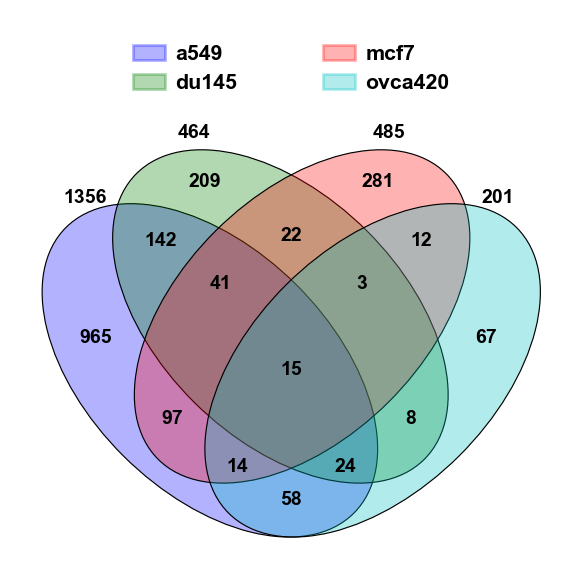

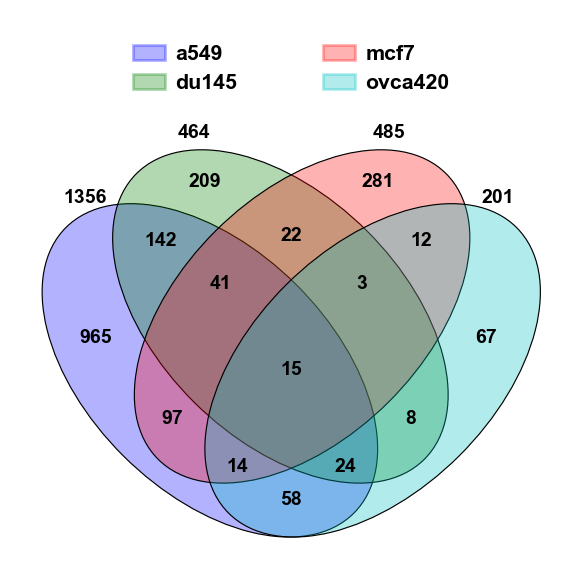

In [25]:
from venny4py.venny4py import *

celltype_sets = {
    "a549": set([i for i in g0_treatment['a549'] if isinstance(i, str)]), "du145": set(g0_treatment['du145']),
    "mcf7": set(g0_treatment['mcf7']), "ovca420": set(g0_treatment['ovca420'])
}
venny4py(sets=celltype_sets)


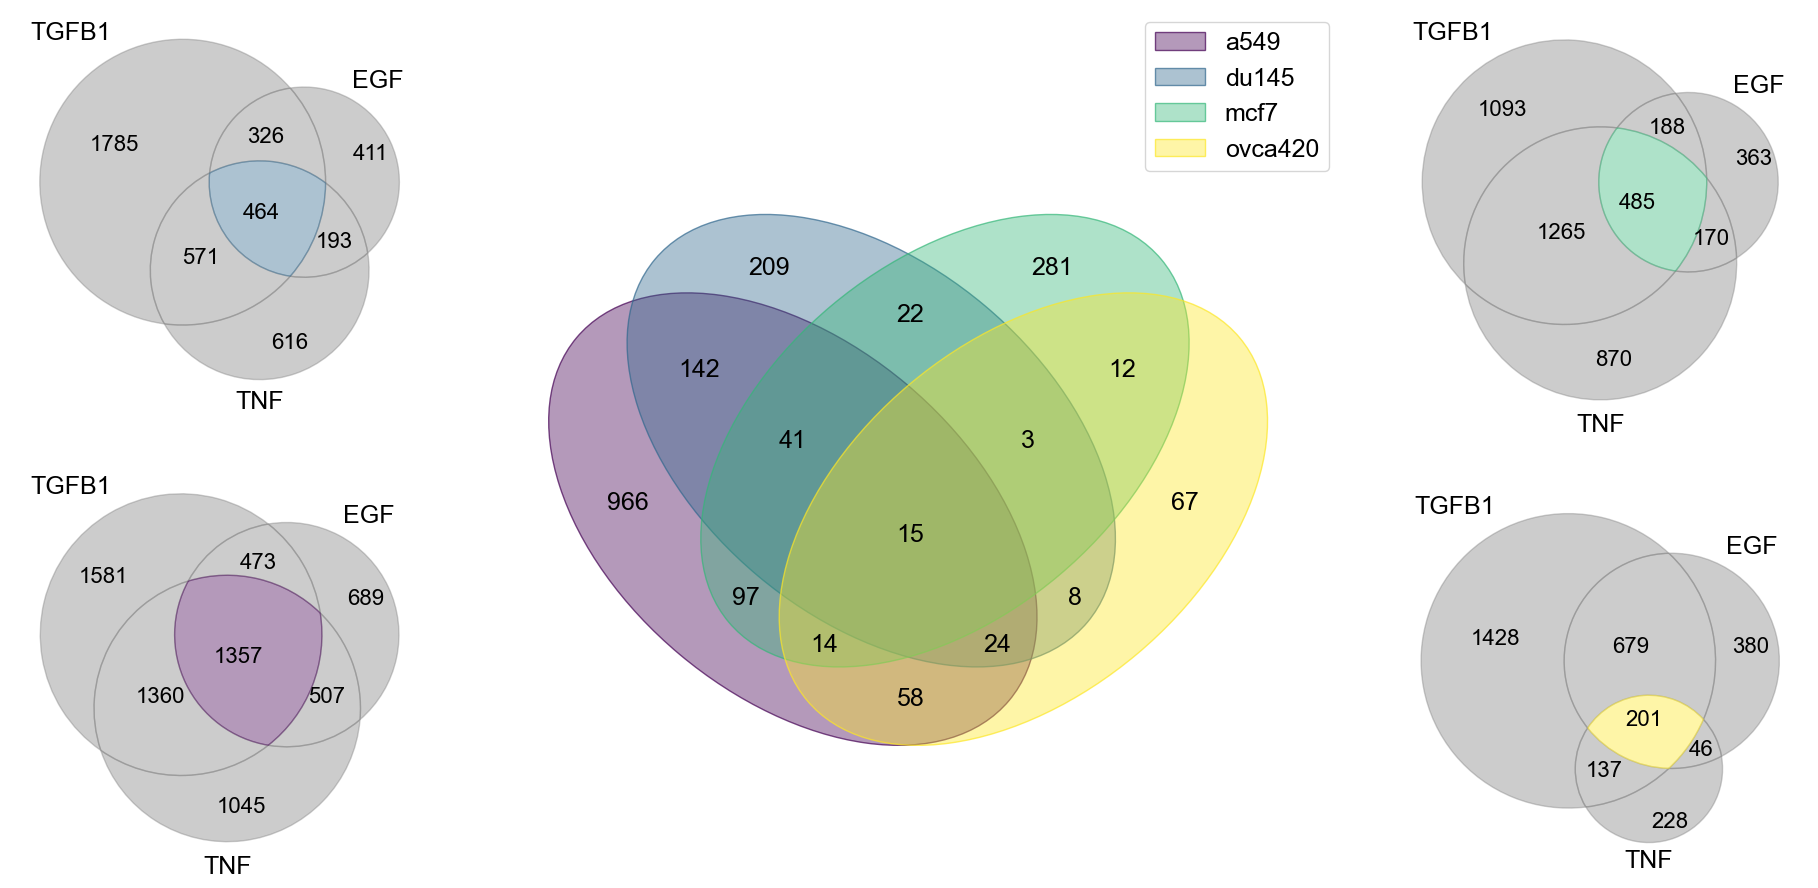

In [47]:
((axes1['du145']/axes1['a549'])|ax1|(axes1['mcf7']/axes1['ovca420'])).savefig(
    f'{PROJECT_location}/figures/Fig_1a_venn_consensus_2.png', dpi=1200
)

In [ ]:
# for the next sections please keep the cooketal data (GSE147405) into the approproiate location

# 1D: PPI p/q

In [37]:
from emt import get_hppin_network, get_fraction_data
hppin = get_hppin_network()

from utils import read_genes

g0b = read_genes("original", 'EMT', None, annotationdf)

from emt import read_emt_consensus_genes
g0a = read_emt_consensus_genes(g0_treatment)

fractions = get_fraction_data(cell_emts_consensus, g0a, g0b)
[(key, sum(val)) for key, val in fractions.items()]


{'SHC1': (0.010309278350515464, 0.011003883723667177)}
{'CDK6': (0.010309278350515464, 0.01056772148182939)}
{'BATF': (0.010309278350515464, 0.010801291458761374), 'EPHA4': (0.010309278350515464, 0.010334703464474456)}
{}


[('a549', 2723.545377602309),
 ('du145', 1098.1999715891957),
 ('mcf7', 978.9975281860516),
 ('ovca420', 293.4695545783703)]

[0.74509804 0.72941176 0.85490196]
[0.50196078 0.69411765 0.82745098]
[0.55294118 0.82745098 0.78039216]
[1.         1.         0.70196078]


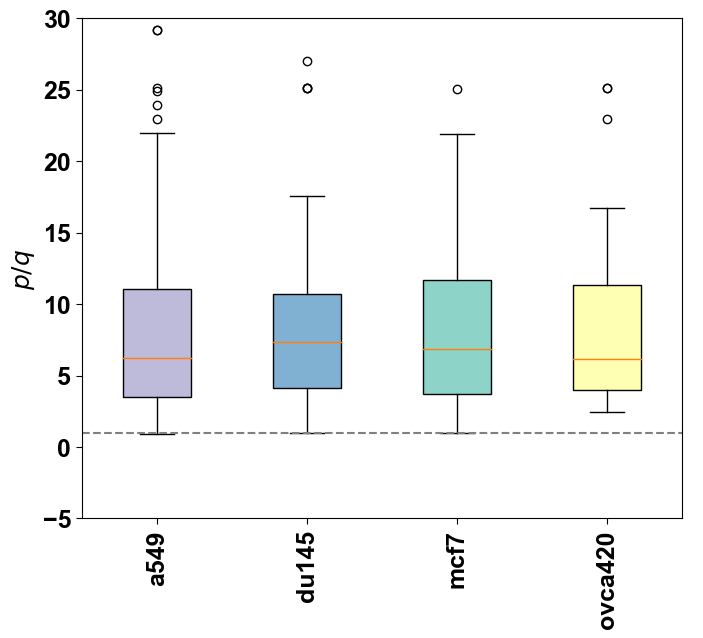

In [158]:
from emt import plot_nw_fractions
from emt import get_hppin_network
# fractions
ppi_ax = plot_nw_fractions(fractions)
# ppi_ax.savefig(f'{PROJECT_location}/figures/Fig_1D_ppi.png')

# 1C: co-expression p/q

In [3]:
# g0a, cell_emts, g0b

from emt import read_emt_treatment_genes
g0_treatment = read_emt_treatment_genes(annotationdf)

from emt import read_emt_consensus_genes
g0a = read_emt_consensus_genes(g0_treatment)

from utils import read_genes
g0b = read_genes("original", 'EMT', None, annotationdf)

from emt import read_emt_context_genes
# cell_emts = read_emt_context_genes(g0_treatment, set(g0a).union(g0b), annotationdf)
cell_emts_consensus = read_emt_context_genes(g0_treatment, g0a, annotationdf)

# CELL_LINES = ['a549', 'du145', 'mcf7', 'ovca420']
# TREATMENTS = ['tgfb1', 'egf', 'tnf']
# CELL_LINE_to_CANCERTYPE = {'a549':'LUAD', 'du145':'PRAD', 'mcf7':'BRCA', 'ovca420':'OV'}
# CELL_LINE_to_tissue = {'a549':'lung', 'du145':'prostate', 'mcf7':'breast', 'ovca420':'ovarian'}

3
a549 7012 (366, 2) 1357
3
du145 4366 (94, 2) 464
3
mcf7 4434 (369, 2) 485
3
ovca420 3099 (455, 2) 201
97
a549 1357 1263 (366, 2)
du145 464 381 (94, 2)
mcf7 485 412 (369, 2)
ovca420 201 145 (455, 2)


<Figure size 100x100 with 0 Axes>

In [94]:
from emt import compute_pq_in_coexpression, get_cross_correlations

# corrdict_context_inPan = compute_pq_in_coexpression(cell_emts_consensus, g0a)
# corrdict_context_inRef = compute_pq_in_coexpression(cell_emts_consensus, g0b['Symbol'].to_list()) #

# with open(f"{PROJECT_location}/data/cooketal/corrdict_context_inPan.pkl", 'wb') as f:
#     pickle.dump(corrdict_context_inPan, f)

with open(f"{PROJECT_location}/cooketal/corrdict_context_inPan.pkl", 'rb') as f:
    corrdict_context_inPan = pickle.load(f)

dict_keys(['a549_tgfb1-pq', 'a549_egf-pq', 'a549_tnf-pq', 'du145_tgfb1-pq', 'du145_egf-pq', 'du145_tnf-pq', 'mcf7_tgfb1-pq', 'mcf7_egf-pq', 'mcf7_tnf-pq', 'ovca420_tgfb1-pq', 'ovca420_egf-pq', 'ovca420_tnf-pq'])

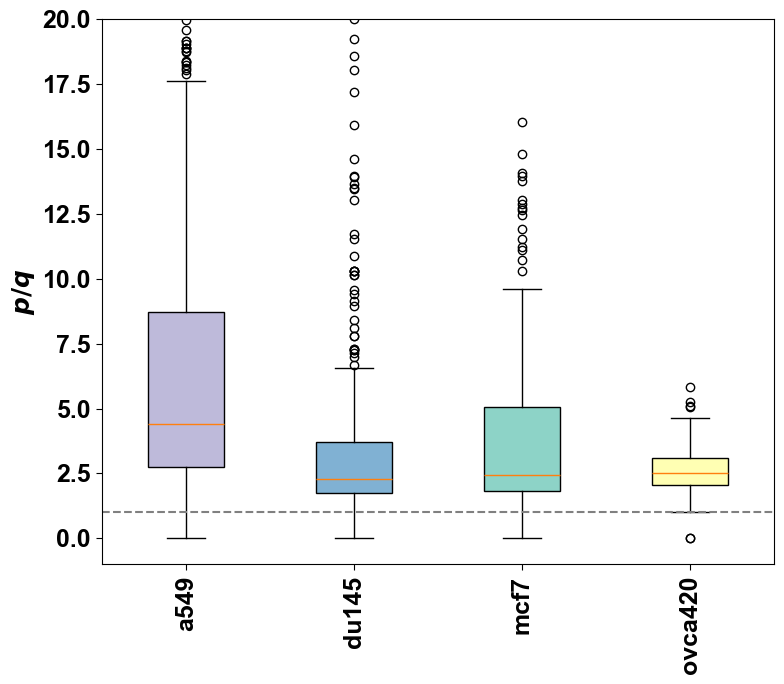

In [153]:
from emt import plot_pq_fractions_in_coexpression

fractions = dict((k.split('_')[0], list(np.array(corrdict_context_inPan[k])[~np.isnan(corrdict_context_inPan[k])])) for k in corrdict_context_inPan.keys() if 'tgfb1' in k)
coppi_ax = plot_pq_fractions_in_coexpression(fractions)
fig.savefig(f'{PROJECT_location}/Figures/Fig_1C_coppi.png')



# 1B: coexpression

In [161]:
from emt import compute_cross_coorelations

cross_corrdict = compute_cross_coorelations(g0a, cell_emts_consensus)
with open(f"{PROJECT_location}/cooketal/cross_corrdict.pkl", 'wb') as f:
    pickle.dump(cross_corrdict, f)

a549_tgfb1 (12926, 1959) 1377
a549_egf (12926, 5574) 4752
a549_tnf (12926, 3112) 2302
du145_tgfb1 (13018, 4184) 3536
du145_egf (13018, 4867) 4383
du145_tnf (13018, 3170) 2462
mcf7_tgfb1 (13379, 1447) 1041
mcf7_egf (13379, 2049) 1587
mcf7_tnf (13379, 1076) 715
ovca420_tgfb1 (13688, 641) 486
ovca420_egf (13688, 1703) 1449
ovca420_tnf (13688, 1462) 1247


In [162]:
cross_corrdict.keys()

dict_keys(['a549_tgfb1-within_consensus', 'a549_tgfb1-within_context', 'a549_tgfb1-consensus_cross_context', 'a549_tgfb1-consensus_cross_random', 'a549_egf-within_consensus', 'a549_egf-within_context', 'a549_egf-consensus_cross_context', 'a549_egf-consensus_cross_random', 'a549_tnf-within_consensus', 'a549_tnf-within_context', 'a549_tnf-consensus_cross_context', 'a549_tnf-consensus_cross_random', 'du145_tgfb1-within_consensus', 'du145_tgfb1-within_context', 'du145_tgfb1-consensus_cross_context', 'du145_tgfb1-consensus_cross_random', 'du145_egf-within_consensus', 'du145_egf-within_context', 'du145_egf-consensus_cross_context', 'du145_egf-consensus_cross_random', 'du145_tnf-within_consensus', 'du145_tnf-within_context', 'du145_tnf-consensus_cross_context', 'du145_tnf-consensus_cross_random', 'mcf7_tgfb1-within_consensus', 'mcf7_tgfb1-within_context', 'mcf7_tgfb1-consensus_cross_context', 'mcf7_tgfb1-consensus_cross_random', 'mcf7_egf-within_consensus', 'mcf7_egf-within_context', 'mcf7_eg

In [8]:
from emt import plot_cross_coexpressions_sub

with open(f"{PROJECT_location}/cooketal/cross_corrdict.pkl", 'rb') as f:
    cross_corrdict = pickle.load(f)
fractions = dict((k.split('_')[0]+'_'+k.split('-')[1], cross_corrdict[k]) for k in cross_corrdict.keys() if 'tgfb1' in k)
print(fractions.keys())
# cor_axes = plot_cross_coexpressions_sub(cross_corrdict)


dict_keys(['a549_within_consensus', 'a549_within_context', 'a549_consensus_cross_context', 'a549_consensus_cross_random', 'du145_within_consensus', 'du145_within_context', 'du145_consensus_cross_context', 'du145_consensus_cross_random', 'mcf7_within_consensus', 'mcf7_within_context', 'mcf7_consensus_cross_context', 'mcf7_consensus_cross_random', 'ovca420_within_consensus', 'ovca420_within_context', 'ovca420_consensus_cross_context', 'ovca420_consensus_cross_random'])


In [19]:
treatment = 'tgfb1'
cell_type = 'ovca420'
print(fractions.keys())

from scipy.stats import ranksums
CELL_LINES = ['a549', 'du145', 'mcf7', 'ovca420']
TREATMENTS = ['tgfb1', 'egf', 'tnf']
for treatment in TREATMENTS:
    for cell_type in CELL_LINES:
        fractions = dict((k, cross_corrdict[k]) for k in cross_corrdict.keys() if cell_type in k and treatment in k)
        res = ranksums(fractions[f'{cell_type}_{treatment}-consensus_cross_context'], fractions[f'{cell_type}_{treatment}-consensus_cross_random'], alternative='greater')
        print(treatment, cell_type, res.pvalue)

dict_keys(['ovca420_tnf-within_consensus', 'ovca420_tnf-within_context', 'ovca420_tnf-consensus_cross_context', 'ovca420_tnf-consensus_cross_random'])
tgfb1 a549 0.0
tgfb1 du145 0.0
tgfb1 mcf7 0.0
tgfb1 ovca420 0.0
egf a549 0.0
egf du145 0.0
egf mcf7 0.0
egf ovca420 0.0
tnf a549 0.0
tnf du145 0.0
tnf mcf7 0.0
tnf ovca420 0.0


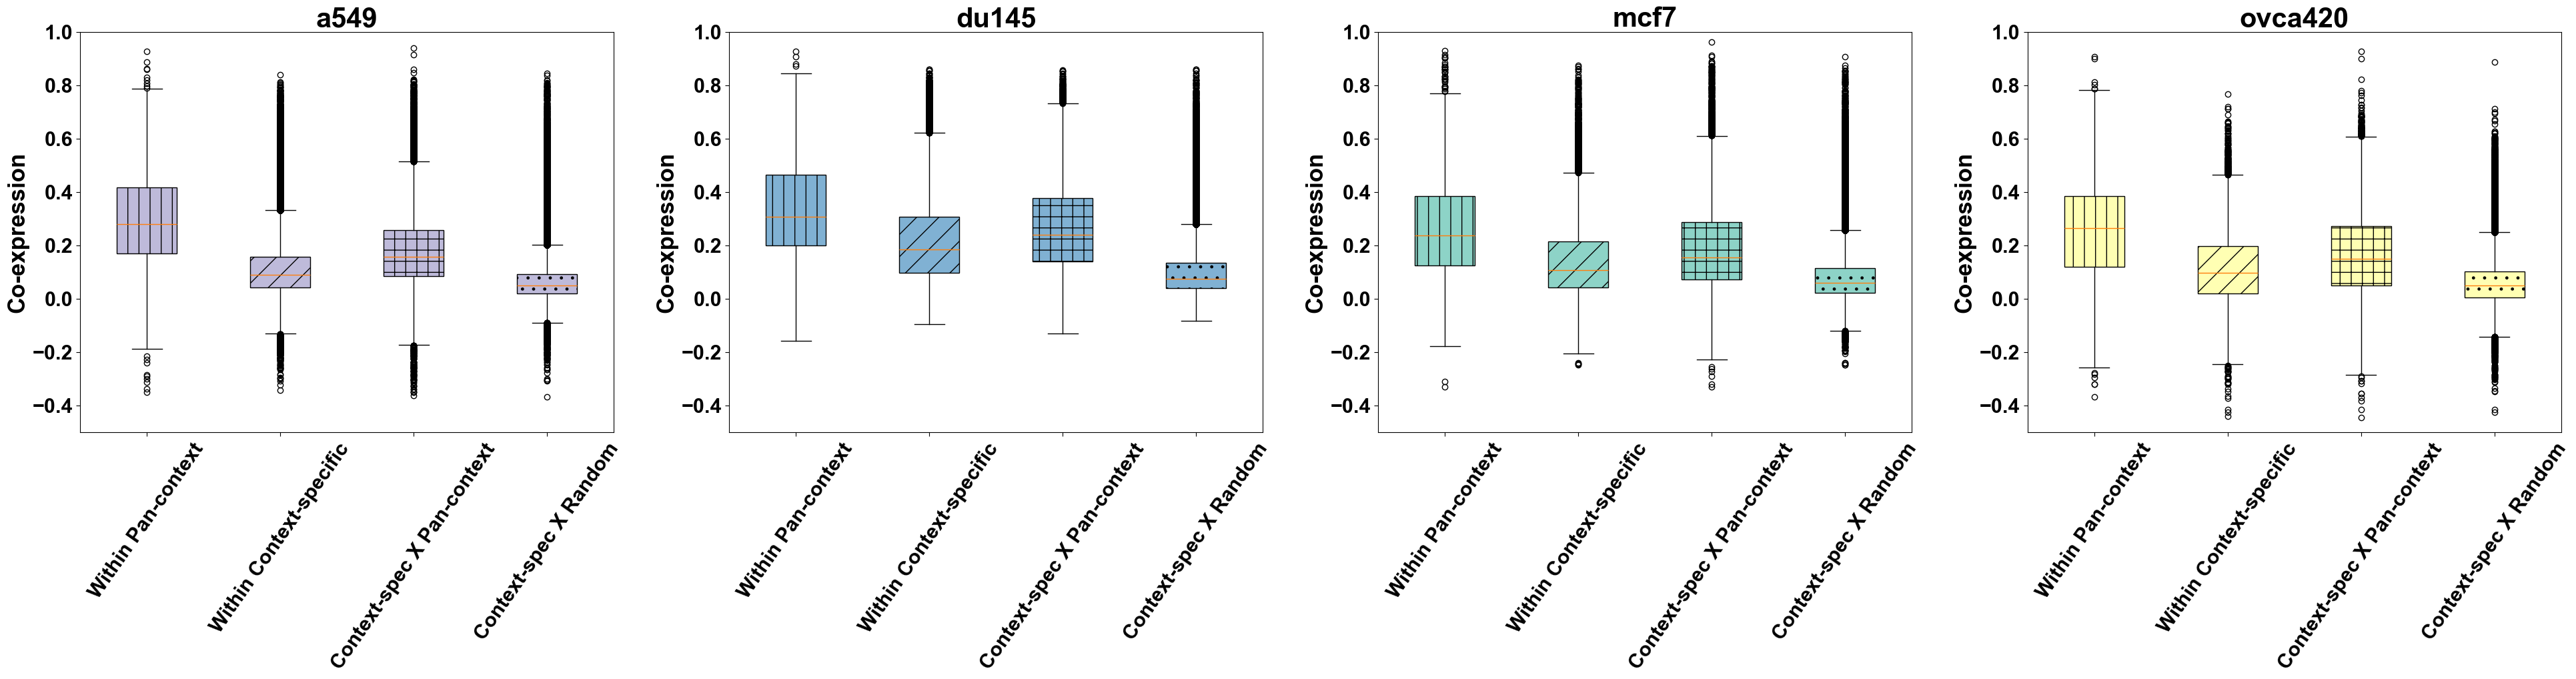

In [5]:
((cor_axes['a549']|cor_axes['du145'])|(cor_axes['mcf7']|cor_axes['ovca420'])).savefig(
    f'{PROJECT_location}/figures/Fig_1B_crosscoexp_patchw.png', dpi=700)